# Assignment 2: Gradient Descent
**Model:** $\hat{y} = c_0 + c_1 e^{c_2 x}$

**Data:** A2.csv (columns X, Y) - downloaded from the link given in A2.pdf

x: (100,), y: (100,)
x: min=0.0108, max=4.9783, mean=2.7306
y: min=0.9493, max=1.9707, mean=1.1195


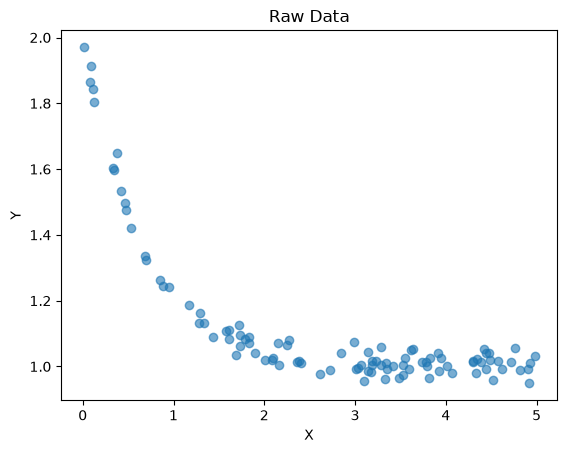

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.genfromtxt('A2.csv', delimiter=',', skip_header=1)
x = data[:, 0]
y = data[:, 1]

print(f'x: {x.shape}, y: {y.shape}')
print(f'x: min={x.min():.4f}, max={x.max():.4f}, mean={x.mean():.4f}')
print(f'y: min={y.min():.4f}, max={y.max():.4f}, mean={y.mean():.4f}')
plt.scatter(x, y, alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Raw Data')
plt.show()

## Task 1: Error/Loss Function (1 point)

Using Mean Squared Error (MSE):

$$L(c_0, c_1, c_2) = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (c_0 + c_1 e^{c_2 x_i}) \right)^2$$

In [2]:
def predict(x, c0, c1, c2):
    return c0 + c1 * np.exp(c2 * x)

def loss(x, y, c0, c1, c2):
    y_hat = predict(x, c0, c1, c2)
    return np.mean((y - y_hat) ** 2)

## Task 2: Gradients of Each Coefficient (3 points)

Let $e_i = \hat{y}_i - y_i$ (residual).

$$\frac{\partial L}{\partial c_0} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot 1 = \frac{2}{n} \sum_{i=1}^{n} e_i$$

$$\frac{\partial L}{\partial c_1} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot e^{c_2 x_i} = \frac{2}{n} \sum_{i=1}^{n} e_i \cdot e^{c_2 x_i}$$

$$\frac{\partial L}{\partial c_2} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot c_1 x_i e^{c_2 x_i} = \frac{2}{n} \sum_{i=1}^{n} e_i \cdot c_1 x_i e^{c_2 x_i}$$

In [3]:
def gradients(x, y, c0, c1, c2):
    n = len(x)
    y_hat = predict(x, c0, c1, c2)
    e = y_hat - y
    exp_c2x = np.exp(c2 * x)

    dc0 = (2.0 / n) * np.sum(e)
    dc1 = (2.0 / n) * np.sum(e * exp_c2x)
    dc2 = (2.0 / n) * np.sum(e * c1 * x * exp_c2x)

    return dc0, dc1, dc2

## Task 3: Update Rules (1 point)

With learning rate $\alpha$:

$$c_0 := c_0 - \alpha \cdot \frac{\partial L}{\partial c_0}$$
$$c_1 := c_1 - \alpha \cdot \frac{\partial L}{\partial c_1}$$
$$c_2 := c_2 - \alpha \cdot \frac{\partial L}{\partial c_2}$$

In [4]:
def update(c0, c1, c2, dc0, dc1, dc2, lr):
    c0 -= lr * dc0
    c1 -= lr * dc1
    c2 -= lr * dc2
    return c0, c1, c2

## Task 4: Gradient Descent Implementation (4 points)

In [5]:
def gradient_descent(x, y, lr=0.01, epochs=50000, c0=0.0, c1=1.0, c2=0.0):
    loss_history = []
    params_history = []

    for i in range(epochs):
        dc0, dc1, dc2 = gradients(x, y, c0, c1, c2)
        c0, c1, c2 = update(c0, c1, c2, dc0, dc1, dc2, lr)

        current_loss = loss(x, y, c0, c1, c2)
        loss_history.append(current_loss)
        params_history.append((c0, c1, c2))

        if i % 5000 == 0:
            print(f'Epoch {i:5d}: loss={current_loss:.6f}, c0={c0:.6f}, c1={c1:.6f}, c2={c2:.6f}')

    return c0, c1, c2, loss_history, params_history

# Run on the given data
c0, c1, c2, loss_hist, params_hist = gradient_descent(
    x, y, lr=0.01, epochs=50000, c0=0.0, c1=1.0, c2=0.0
)

print(f'\nFinal: c0={c0:.6f}, c1={c1:.6f}, c2={c2:.6f}')

Epoch     0: loss=0.064828, c0=0.002390, c1=1.002390, c2=0.001588
Epoch  5000: loss=0.016818, c0=0.438538, c1=1.135327, c2=-0.204722
Epoch 10000: loss=0.008542, c0=0.845052, c1=0.873511, c2=-0.543035


Epoch 15000: loss=0.002015, c0=0.971808, c1=0.897230, c2=-1.058687
Epoch 20000: loss=0.001117, c0=0.988180, c1=0.943416, c2=-1.259935
Epoch 25000: loss=0.000883, c0=0.994708, c1=0.965967, c2=-1.363931


Epoch 30000: loss=0.000805, c0=0.998073, c1=0.978465, c2=-1.424295
Epoch 35000: loss=0.000776, c0=1.000010, c1=0.985929, c2=-1.461400
Epoch 40000: loss=0.000764, c0=1.001193, c1=0.990581, c2=-1.484952


Epoch 45000: loss=0.000759, c0=1.001939, c1=0.993555, c2=-1.500192

Final: c0=1.002420, c1=0.995488, c2=-1.510170


## Task 5: Loss Over Iterations and Resulting Coefficients (1 point)

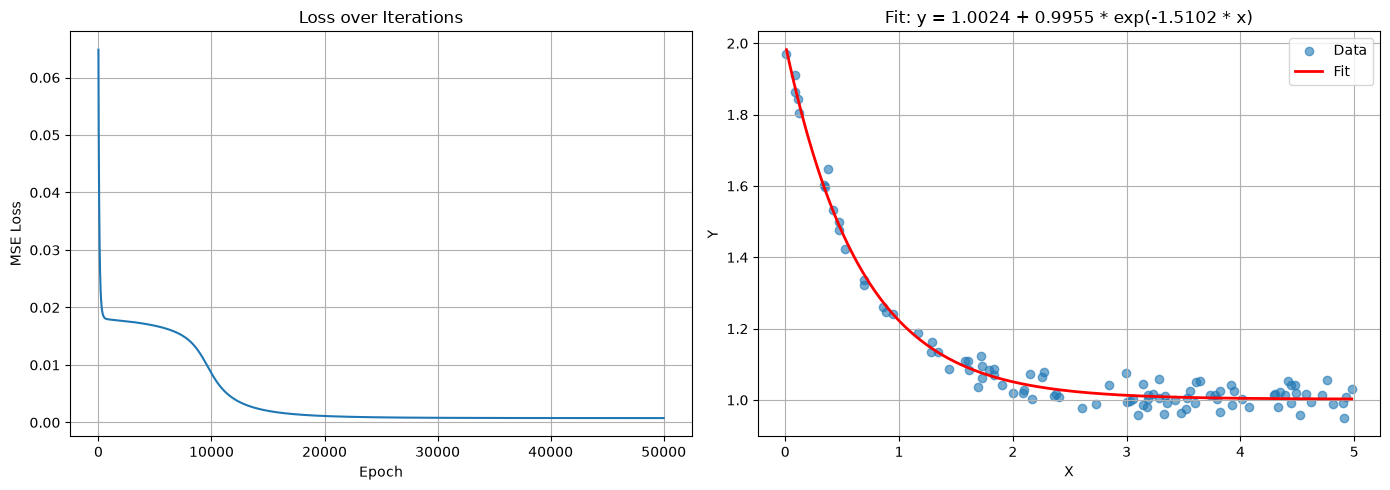

Resulting coefficients:
  c0 = 1.002420
  c1 = 0.995488
  c2 = -1.510170
Final loss: 0.000757


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss over iterations
axes[0].plot(loss_hist)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss over Iterations')
axes[0].grid(True)

# Fit result
x_line = np.linspace(x.min(), x.max(), 300)
y_line = predict(x_line, c0, c1, c2)

axes[1].scatter(x, y, alpha=0.6, label='Data')
axes[1].plot(x_line, y_line, 'r-', linewidth=2, label='Fit')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title(f'Fit: y = {c0:.4f} + {c1:.4f} * exp({c2:.4f} * x)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print('Resulting coefficients:')
print(f'  c0 = {c0:.6f}')
print(f'  c1 = {c1:.6f}')
print(f'  c2 = {c2:.6f}')
print(f'Final loss: {loss_hist[-1]:.6f}')